Целевой признак Credit_Score

Выясните, клиенты с каким значением признака Payment_Behaviour более склонны к просрочкам по кредиту (Credit_Score=Poor)?



In [ ]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.metrics import classification_report, roc_auc_score, f1_score, mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.pipeline import Pipeline
from statsmodels.stats.weightstats import ttest_ind

In [ ]:
df = pd.read_csv('train.csv')
df

/tmp/ipykernel_2418/2339890750.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('train.csv')


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
99996,0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
99997,0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor
99998,0x25fec,CUS_0x942c,July,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard


In [ ]:
df['Payment_Behaviour'].value_counts()


,count
Payment_Behaviour,
Low_spent_Small_value_payments,25513
High_spent_Medium_value_payments,17540
Low_spent_Medium_value_payments,13861
High_spent_Large_value_payments,13721
High_spent_Small_value_payments,11340
Low_spent_Large_value_payments,10425
!@9#%8,7600


In [ ]:
df.groupby('Payment_Behaviour').size()

,0
Payment_Behaviour,
!@9#%8,7600
High_spent_Large_value_payments,13721
High_spent_Medium_value_payments,17540
High_spent_Small_value_payments,11340
Low_spent_Large_value_payments,10425
Low_spent_Medium_value_payments,13861
Low_spent_Small_value_payments,25513


In [ ]:

print("Количество просрочек (Credit_Score=Poor) по категориям Payment_Behaviour:")
# df[df['Credit_Score'] == 'Poor'].groupby('Payment_Behaviour').size()


print( df[df['Credit_Score'] == 'Poor']['Credit_Score'].groupby(df['Payment_Behaviour']).count())
df[df['Credit_Score'] == 'Poor']['Credit_Score'].groupby(df['Payment_Behaviour']).size() / df.groupby('Payment_Behaviour').size()

Количество просрочек (Credit_Score=Poor) по категориям Payment_Behaviour:
Payment_Behaviour
!@9#%8                              2225
High_spent_Large_value_payments     2979
High_spent_Medium_value_payments    4439
High_spent_Small_value_payments     3088
Low_spent_Large_value_payments      2931
Low_spent_Medium_value_payments     4211
Low_spent_Small_value_payments      9125
Name: Credit_Score, dtype: int64


,0
Payment_Behaviour,
!@9#%8,0.292763
High_spent_Large_value_payments,0.217112
High_spent_Medium_value_payments,0.253079
High_spent_Small_value_payments,0.272310
Low_spent_Large_value_payments,0.281151
Low_spent_Medium_value_payments,0.303802
Low_spent_Small_value_payments,0.357661


Продолжайте работать с датасетом для предсказания кредитного дефолта.

В данных есть заведомо неинформативные столбцы, поэтому их нужно удалить.

Укажите в ответе названия этих столбцов через пробел в одной строке.

Формат ответа:  Признак1 Признак2
В ответе может быть любое количество признаков.

Удалите явные пропуски в данных. Изучите признаки в датасете, убедитесь, что типы данных соответствуют значениям в признаке.

А именно, если есть несостыковки по типам данных (значение численное, но записано неверно (к примеру, вместо 34847.84 записано ?34847.84_)), то удалите эти объекты (для удобства можете эти значения переводить в NaN).

Оставьте в выборке только численные признаки.

Укажите в ответе, сколько осталось объектов в выборке.

In [ ]:
df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0


In [ ]:
df.info()
df = df.drop(['ID', 'Customer_ID', 'Name', 'SSN'], axis=1)


numeric_cols = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
                'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
                'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
                'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month',
                'Amount_invested_monthly', 'Monthly_Balance']

def clean_value(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, str):
        # Удаляем все символы кроме цифр, точки и минуса
        cleaned = re.sub(r'[^\d.-]', '', x)
        if cleaned == '' or cleaned == '-' or cleaned == '.':
            return np.nan
        try:
            return float(cleaned)
        except:
            return np.nan
    return x

# Очищаем числовые столбцы
for col in numeric_cols:
    df[col] = df[col].apply(clean_value)

df_clean = df.dropna(subset=numeric_cols)

# Также удаляем явные выбросы (например, возраст > 100 или отрицательный)
df_clean = df_clean[(df_clean['Age'] > 0) & (df_clean['Age'] < 100)]
df_clean = df_clean[df_clean['Annual_Income'] > 0]
df_clean = df_clean[df_clean['Num_Bank_Accounts'] > 0]
df_clean = df_clean[df_clean['Num_Credit_Card'] > 0]
df_clean = df_clean[df_clean['Interest_Rate'] >= 0]
df_clean = df_clean[df_clean['Num_of_Loan'] >= 0]



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [ ]:
import pandas as pd
import numpy as np

# Загружаем данные
file_path = 'train.csv'
data = pd.read_csv(file_path)

print(f"Исходный размер данных: {data.shape}")

# 1. Удаление заведомо неинформативных столбцов
columns_to_drop = ['ID', 'Customer_ID', 'Name', 'SSN']
data = data.drop(columns=[col for col in columns_to_drop if col in data.columns], errors='ignore')
print(f"Размер после удаления неинформативных столбцов: {data.shape}")

# 2. Функция для очистки числовых значений
def clean_numeric(value):
    if pd.isna(value):
        return np.nan
    # Если это число, просто возвращаем его
    if isinstance(value, (int, float)):
        return value
    # Если это строка, пытаемся очистить
    if isinstance(value, str):
        # Удаляем символы подчеркивания, решетки и другие некорректные символы
        # Оставляем только цифры, точку и минус
        cleaned = ''.join(c for c in value if c.isdigit() or c == '.' or c == '-')
        if cleaned == '' or cleaned == '.' or cleaned == '-':
            return np.nan
        try:
            # Пробуем преобразовать в float
            return float(cleaned)
        except ValueError:
            return np.nan
    return np.nan

# 3. Список числовых признаков (на основе анализа данных)
# Выбраны все признаки, которые по смыслу должны быть числовыми
numeric_features = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance'
]

# Применяем очистку для каждого числового признака
for col in numeric_features:
    if col in data.columns:
        data[col] = data[col].apply(clean_numeric)

print("Применили очистку числовых признаков")

# 4. Удаляем строки с явными пропусками (NaN) в любом из столбцов
initial_rows = len(data)
data_clean = data.dropna()

print(f"Удалили {initial_rows - len(data_clean)} строк с пропусками")

# 5. Оставляем только числовые признаки
# Сначала определяем, какие столбцы остались после удаления неинформативных
all_columns = data_clean.columns.tolist()

# Список числовых признаков, которые мы очищали + потенциально другие числовые
final_numeric_features = []

for col in all_columns:
    # Пытаемся преобразовать в числовой тип
    try:
        # Если столбец уже числовой или может быть преобразован в числовой
        if pd.api.types.is_numeric_dtype(data_clean[col]):
            final_numeric_features.append(col)
        else:
            # Если это не числовой столбец, пробуем его исключить
            # (это будут категориальные признаки, которые мы не включаем в ответ)
            pass
    except:
        pass

# Создаем датасет только с числовыми признаками
data_numeric_only = data_clean[final_numeric_features]

print(f"Размер итоговой выборки (только числовые признаки): {data_numeric_only.shape}")

# 6. Выводим количество оставшихся объектов
result_count = data_numeric_only.shape[0]
print(f"\nКоличество объектов в выборке: {result_count}")

# Сохраняем результат для проверки
data_numeric_only.to_csv('train_cleaned_numeric.csv', index=False)

/tmp/ipykernel_2418/819042961.py:6: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


Исходный размер данных: (100000, 28)
Размер после удаления неинформативных столбцов: (100000, 24)
Применили очистку числовых признаков
Удалили 42300 строк с пропусками
Размер итоговой выборки (только числовые признаки): (57700, 16)

Количество объектов в выборке: 57700


In [ ]:
data_numeric_only


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
0,23.0,19114.12,1824.843333,3,4,3,4.0,3,7.0,11.27,4.0,809.98,26.822620,49.574949,80.415295,312.494089
6,23.0,19114.12,1824.843333,3,4,3,4.0,3,8.0,11.27,4.0,809.98,22.537593,49.574949,178.344067,244.565317
8,28.0,34847.84,3037.986667,2,4,6,1.0,3,4.0,5.42,2.0,605.03,24.464031,18.816215,104.291825,470.690627
9,28.0,34847.84,3037.986667,2,4,6,1.0,7,1.0,7.42,2.0,605.03,38.550848,18.816215,40.391238,484.591214
10,28.0,34847.84,3037.986667,2,1385,6,1.0,3,-1.0,5.42,2.0,605.03,33.224951,18.816215,58.515976,466.466476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,25.0,39628.99,3359.415833,4,6,7,2.0,20,6.0,9.50,3.0,502.38,39.323569,35.104023,140.581403,410.256158
99995,25.0,39628.99,3359.415833,4,6,7,2.0,23,7.0,11.50,3.0,502.38,34.663572,35.104023,60.971333,479.866228
99996,25.0,39628.99,3359.415833,4,6,7,2.0,18,7.0,11.50,3.0,502.38,40.565631,35.104023,54.185950,496.651610
99997,25.0,39628.99,3359.415833,4,6,5729,2.0,27,6.0,11.50,3.0,502.38,41.255522,35.104023,24.028477,516.809083


In [ ]:
print(f"Количество объектов после очистки: {len(data_numeric_only)}")
print(f"Количество объектов first: {len(df)}")

Количество объектов после очистки: 57700
Количество объектов first: 100000


In [ ]:
data_numeric_only['Credit_Score'] = data_clean['Credit_Score']

/tmp/ipykernel_2418/2449056889.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_numeric_only['Credit_Score'] = data_clean['Credit_Score']


In [ ]:
data_numeric_only

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score
0,23.0,19114.12,1824.843333,3,4,3,4.0,3,7.0,11.27,4.0,809.98,26.822620,49.574949,80.415295,312.494089,Good
6,23.0,19114.12,1824.843333,3,4,3,4.0,3,8.0,11.27,4.0,809.98,22.537593,49.574949,178.344067,244.565317,Good
8,28.0,34847.84,3037.986667,2,4,6,1.0,3,4.0,5.42,2.0,605.03,24.464031,18.816215,104.291825,470.690627,Standard
9,28.0,34847.84,3037.986667,2,4,6,1.0,7,1.0,7.42,2.0,605.03,38.550848,18.816215,40.391238,484.591214,Good
10,28.0,34847.84,3037.986667,2,1385,6,1.0,3,-1.0,5.42,2.0,605.03,33.224951,18.816215,58.515976,466.466476,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,25.0,39628.99,3359.415833,4,6,7,2.0,20,6.0,9.50,3.0,502.38,39.323569,35.104023,140.581403,410.256158,Poor
99995,25.0,39628.99,3359.415833,4,6,7,2.0,23,7.0,11.50,3.0,502.38,34.663572,35.104023,60.971333,479.866228,Poor
99996,25.0,39628.99,3359.415833,4,6,7,2.0,18,7.0,11.50,3.0,502.38,40.565631,35.104023,54.185950,496.651610,Poor
99997,25.0,39628.99,3359.415833,4,6,5729,2.0,27,6.0,11.50,3.0,502.38,41.255522,35.104023,24.028477,516.809083,Poor


Сделайте разбиение на обучение и тест с соотношением 80/20, со стратификацией по целевому признаку и random_state=1.

Выполните обучение модели SVC с параметрами по умолчанию.

Выведите опорные векторы (для этого используйте атрибут .support_vectors_).

В ответе укажите количество векторов.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

x = data_numeric_only.drop(columns = 'Credit_Score').values
y = data_numeric_only['Credit_Score'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify = y, random_state = 1)

model = SVC(random_state = 1)
model.fit(x_train, y_train)

SVC(random_state=1)

In [ ]:
len(model.support_vectors_)

# 36227

36227

In [ ]:
len(x_train)

46160

Чтобы модель быстрее обучалась возьмите выборку меньшей размерности - на тренировочной выборке оставьте 10000 случайных объектов, а на тесте - 2000.

Получайте индексы объектов через np.random.choice с replace=False, зафиксируйте случайность для трейна через np.random.seed(1), а для теста - np.random.seed(2).

Обучите еще раз модели SVC на параметрах по умолчанию, но перед этим сделайте масштабирование данных через стандартизацию, можете воспользоваться методом make_pipeline

Сделайте предсказания моделью на тестовой выборке и посчитайте метрику recall для каждого класса. Для удобства можете воспользоваться функцией classification_report.

Укажите в ответе значения метрик, округлив их до второго знака после точки.

In [ ]:
np.random.seed(1)
train_indices = np.random.choice(len(x), size=10000, replace=False)

# np.random.seed(2)
# test_indices = np.random.choice(len(x), size=2000, replace=False)

remaining_indices = np.setdiff1d(np.arange(len(x)), train_indices)
np.random.seed(2)
test_indices = np.random.choice(remaining_indices, size=2000, replace=False)


x_train_sm = x[train_indices]
y_train_sm = y[train_indices]

x_test_sm = x[test_indices]
y_test_sm = y[test_indices]


from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

pipe = make_pipeline( StandardScaler(), SVC())

pipe.fit(x_train_sm, y_train_sm)

y_pred_sm = pipe.predict(x_test_sm)

print(classification_report(y_test_sm, y_pred_sm))

              precision    recall  f1-score   support

        Good       0.54      0.02      0.04       304
        Poor       0.68      0.51      0.58       610
    Standard       0.62      0.86      0.72      1086

    accuracy                           0.63      2000
   macro avg       0.61      0.47      0.45      2000
weighted avg       0.62      0.63      0.58      2000



У модели SVC изменяйте ядра: ['linear', 'rbf', 'poly'], другие параметры оставьте по умолчанию.

Используйте масштабированные данные.

Укажите в ответе ядро, при котором получилась самая высокая метрика на тесте recall с макро усреднением.

In [ ]:
kernel = ['linear', 'rbf', 'poly']

from sklearn.metrics import recall_score

for el in kernel:

  pipe_el = make_pipeline( StandardScaler(), SVC( kernel = el ))

  pipe_el.fit(x_train_sm, y_train_sm)

  y_pred_sm_el = pipe_el.predict(x_test_sm)

  print(el)
  print(recall_score(y_test_sm, y_pred_sm_el, average = 'macro'))

linear
0.42824957994928486
rbf
0.4581195019015268
poly
0.3961488662987462


У модели SVC возьмите самое лучшее ядро с предыдущего задания, другие параметры оставьте по умолчанию.

Подберите самое лучшее значение параметра C из списка [0.001, 0.01, 0.1, 1, 10, 100].

Используйте масштабированные данные.

Визуализируйте изменение метрики recall_macro на тренировочной и тестовой выборках от параметра C.

Укажите в ответе значение C, при котором получилась самая высокая метрика на тесте recall с макро усреднением.

In [ ]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

train_recall_macro = []
test_recall_macro = []

for C in C_values:
    print(f"\nОбучение с C = {C}...")

    pipe_c = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=C))

    pipe_c.fit(x_train_sm, y_train_sm)

    y_train_pred_c = pipe_c.predict(x_train_sm)
    recall_train = recall_score(y_train_sm, y_train_pred_c, average='macro')
    train_recall_macro.append(recall_train)

    # Предсказания на тестовой выборке
    y_test_pred_c = pipe_c.predict(x_test_sm)
    recall_test = recall_score(y_test_sm, y_test_pred_c, average='macro')
    test_recall_macro.append(recall_test)

    print(f"  Recall macro на train: {recall_train:.4f}")
    print(f"  Recall macro на test:  {recall_test:.4f}")





Обучение с C = 0.001...
  Recall macro на train: 0.3333
  Recall macro на test:  0.3333

Обучение с C = 0.01...
  Recall macro на train: 0.4075
  Recall macro на test:  0.3975

Обучение с C = 0.1...
  Recall macro на train: 0.4439
  Recall macro на test:  0.4312

Обучение с C = 1...
  Recall macro на train: 0.4863
  Recall macro на test:  0.4581

Обучение с C = 10...
  Recall macro на train: 0.5515
  Recall macro на test:  0.4763

Обучение с C = 100...
  Recall macro на train: 0.6250
  Recall macro на test:  0.5181


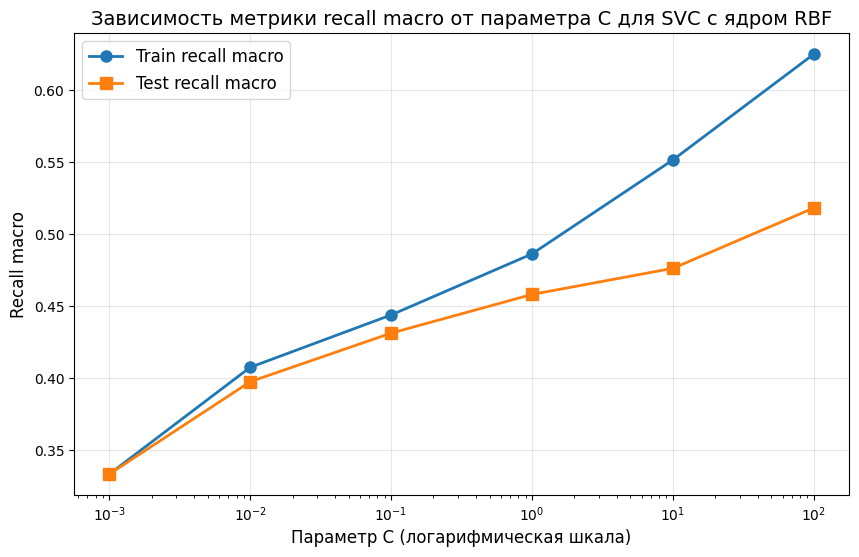

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_recall_macro, 'o-', label='Train recall macro', linewidth=2, markersize=8)
plt.plot(C_values, test_recall_macro, 's-', label='Test recall macro', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('Параметр C (логарифмическая шкала)', fontsize=12)
plt.ylabel('Recall macro', fontsize=12)
plt.title('Зависимость метрики recall macro от параметра C для SVC с ядром RBF', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)